# LAYOUT OF PROJECT

## Q: How have the characteristics of Billboard Hot 100 songs changed between 2020 and 2025 using Spotify track data?

## Are songs getting shorter?

## Are songs becoming more explicit?

## Are collaborations increasing?

In [1]:
#packages
import pandas as pd
import requests
import time
import spotipy
import re
import seaborn as sns
import matplotlib.pyplot as plt
from spotipy.oauth2 import SpotifyClientCredentials

In [2]:
# wiki links to the billboard top 100 for years 2020 thru 2025

wiki2020_url = "https://en.wikipedia.org/wiki/Billboard_Year-End_Hot_100_singles_of_2020"
wiki2021_url = "https://en.wikipedia.org/wiki/Billboard_Year-End_Hot_100_singles_of_2021"
wiki2022_url = "https://en.wikipedia.org/wiki/Billboard_Year-End_Hot_100_singles_of_2022"
wiki2023_url = "https://en.wikipedia.org/wiki/Billboard_Year-End_Hot_100_singles_of_2023"
wiki2024_url = "https://en.wikipedia.org/wiki/Billboard_Year-End_Hot_100_singles_of_2024"
wiki2025_url = "https://en.wikipedia.org/wiki/Billboard_Year-End_Hot_100_singles_of_2025"

In [3]:
headers = {
    'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; rv:145.0) Gecko/20100101 Firefox/145.0'
}

# function to scrape the main billboard table from wikipedia
def get_billboard_table(url, year):

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    tables = pd.read_html(response.text)

    # first table contains the song data
    df = tables[0]  
    
    # rename columns
    df = df.rename(columns={
        "No.": "rank",
        "Title": "song",
        "Artist(s)": "artist"
    })
    # remove quotation marks from song titles
    df["song"] = df["song"].str.replace('"', '')
    df["year"] = year

    return df

In [4]:
df2020 = get_billboard_table(wiki2020_url, 2020)
df2021 = get_billboard_table(wiki2021_url, 2021)
df2022 = get_billboard_table(wiki2022_url, 2022)
df2023 = get_billboard_table(wiki2023_url, 2023)
df2024 = get_billboard_table(wiki2024_url, 2024)
df2025 = get_billboard_table(wiki2025_url, 2025)

In [5]:
df2020.head(10)

,rank,song,artist,year
0,1,Blinding Lights,The Weeknd,2020
1,2,Circles,Post Malone,2020
2,3,The Box,Roddy Ricch,2020
3,4,Don't Start Now,Dua Lipa,2020
4,5,Rockstar,DaBaby featuring Roddy Ricch,2020
5,6,Adore You,Harry Styles,2020
6,7,Life Is Good,Future featuring Drake,2020
7,8,Memories,Maroon 5,2020
8,9,The Bones,Maren Morris,2020
9,10,Someone You Loved,Lewis Capaldi,2020


In [6]:
df2021.head(10)

,rank,song,artist,year
0,1,Levitating,Dua Lipa,2021
1,2,Save Your Tears,The Weeknd and Ariana Grande,2021
2,3,Blinding Lights,The Weeknd,2021
3,4,Mood,24kGoldn featuring Iann Dior,2021
4,5,Good 4 U,Olivia Rodrigo,2021
5,6,Kiss Me More,Doja Cat featuring SZA,2021
6,7,Leave the Door Open,Silk Sonic (Bruno Mars and Anderson .Paak),2021
7,8,Drivers License,Olivia Rodrigo,2021
8,9,Montero (Call Me by Your Name),Lil Nas X,2021
9,10,Peaches,Justin Bieber featuring Daniel Caesar and Giveon,2021


In [7]:
df2022.head(10)

,rank,song,artist,year
0,1,Heat Waves,Glass Animals,2022
1,2,As It Was,Harry Styles,2022
2,3,Stay,The Kid Laroi and Justin Bieber,2022
3,4,Easy on Me,Adele,2022
4,5,Shivers,Ed Sheeran,2022
5,6,First Class,Jack Harlow,2022
6,7,Big Energy,Latto,2022
7,8,Ghost,Justin Bieber,2022
8,9,Super Gremlin,Kodak Black,2022
9,10,Cold Heart (Pnau Remix),Elton John and Dua Lipa,2022


In [8]:
df2023.head(10)

,rank,song,artist,year
0,1,Last Night,Morgan Wallen,2023
1,2,Flowers,Miley Cyrus,2023
2,3,Kill Bill,SZA,2023
3,4,Anti-Hero,Taylor Swift,2023
4,5,Creepin',"Metro Boomin, the Weeknd and 21 Savage",2023
5,6,Calm Down,Rema and Selena Gomez,2023
6,7,Die for You,The Weeknd and Ariana Grande,2023
7,8,Fast Car,Luke Combs,2023
8,9,Snooze,SZA,2023
9,10,I'm Good (Blue),David Guetta and Bebe Rexha,2023


In [9]:
df2024.head(10)

,rank,song,artist,year
0,1,Lose Control,Teddy Swims,2024
1,2,A Bar Song (Tipsy),Shaboozey,2024
2,3,Beautiful Things,Benson Boone,2024
3,4,I Had Some Help,Post Malone featuring Morgan Wallen,2024
4,5,Lovin on Me,Jack Harlow,2024
5,6,Not Like Us,Kendrick Lamar,2024
6,7,Espresso,Sabrina Carpenter,2024
7,8,Million Dollar Baby,Tommy Richman,2024
8,9,I Remember Everything,Zach Bryan featuring Kacey Musgraves,2024
9,10,Too Sweet,Hozier,2024


In [10]:
df2025.head(10)

,rank,song,artist,year
0,1,Die with a Smile,Lady Gaga and Bruno Mars,2025
1,2,Luther,Kendrick Lamar and SZA,2025
2,3,A Bar Song (Tipsy),Shaboozey,2025
3,4,Lose Control,Teddy Swims,2025
4,5,Birds of a Feather,Billie Eilish,2025
5,6,Beautiful Things,Benson Boone,2025
6,7,Ordinary,Alex Warren,2025
7,8,I Had Some Help,Post Malone featuring Morgan Wallen,2025
8,9,APT.,Rosé and Bruno Mars,2025
9,10,Pink Pony Club,Chappell Roan,2025


In [11]:
# combine all datasets into one dataframe
allsongs = pd.concat([df2020, df2021, df2022, df2023, df2024, df2025], ignore_index=True)

allsongs

,rank,song,artist,year
0,1,Blinding Lights,The Weeknd,2020
1,2,Circles,Post Malone,2020
2,3,The Box,Roddy Ricch,2020
3,4,Don't Start Now,Dua Lipa,2020
4,5,Rockstar,DaBaby featuring Roddy Ricch,2020
...,...,...,...,...
595,96,Dark Thoughts,Lil Tecca,2025
596,97,No Pole,Don Toliver,2025
597,98,Folded,Kehlani,2025
598,99,Superman,Morgan Wallen,2025


In [12]:
#seperate column where we only get the main artist for each song (exclude the collabs)
allsongs["artist_clean"] = allsongs["artist"].str.replace(
    r" featuring.*| and .*|,.*|:.*",
    "",
    regex=True
)

allsongs

,rank,song,artist,year,artist_clean
0,1,Blinding Lights,The Weeknd,2020,The Weeknd
1,2,Circles,Post Malone,2020,Post Malone
2,3,The Box,Roddy Ricch,2020,Roddy Ricch
3,4,Don't Start Now,Dua Lipa,2020,Dua Lipa
4,5,Rockstar,DaBaby featuring Roddy Ricch,2020,DaBaby
...,...,...,...,...,...
595,96,Dark Thoughts,Lil Tecca,2025,Lil Tecca
596,97,No Pole,Don Toliver,2025,Don Toliver
597,98,Folded,Kehlani,2025,Kehlani
598,99,Superman,Morgan Wallen,2025,Morgan Wallen


# SPOTIFY API LOOP

In [13]:
auth = SpotifyClientCredentials(
    client_id="59abef1c93664f729212bf0674ebc4cf", #id from spotify
    client_secret="c3c5a6b568b44e05b12f827bbc6b5f29"
)

sp = spotipy.Spotify(auth_manager=auth)

In [14]:
# create lists to store spotify data
durations = []
explicit_flags = []

# loop through every song and search spotify
for i, row in allsongs.iterrows():
    
    # search query uses song title and main artist
    query = f'{row["song"]} {row["artist_clean"]}'.replace('"','')

    result = sp.search(
        q=query,
        type="track",
        limit=1,
        market="US"
    )
        
    # if spotify returns a track, save its data
    if result["tracks"]["items"]:
        track = result["tracks"]["items"][0]

        durations.append(track.get("duration_ms"))
        explicit_flags.append(track.get("explicit"))

    # if nothing is found, we store missing values
    else:
        durations.append(None)
        explicit_flags.append(None)
    
    # avoid the rate limits
    time.sleep(1)

allsongs["duration_ms"] = durations
allsongs["explicit"] = explicit_flags

In [15]:
# save the dataset to csv in case we hit api limits
allsongs.to_csv("spotify_billboard_data.csv", index=False)

In [16]:
allsongs = pd.read_csv("spotify_billboard_data.csv")

In [19]:
allsongs.head(20)

,rank,song,artist,year,artist_clean,duration_ms,explicit
0,1,Blinding Lights,The Weeknd,2020,The Weeknd,200040,False
1,2,Circles,Post Malone,2020,Post Malone,215280,False
2,3,The Box,Roddy Ricch,2020,Roddy Ricch,196652,True
3,4,Don't Start Now,Dua Lipa,2020,Dua Lipa,183290,False
4,5,Rockstar,DaBaby featuring Roddy Ricch,2020,DaBaby,181733,True
5,6,Adore You,Harry Styles,2020,Harry Styles,207139,False
6,7,Life Is Good,Future featuring Drake,2020,Future,237735,True
7,8,Memories,Maroon 5,2020,Maroon 5,189486,False
8,9,The Bones,Maren Morris,2020,Maren Morris,197298,False
9,10,Someone You Loved,Lewis Capaldi,2020,Lewis Capaldi,182160,False


In [20]:
# create a column that identifies collaborations
allsongs["collab"] = allsongs["artist"].str.contains(
    r"featuring| and | & |,| x |:", # keywords for collabs
    case=False,
    regex=True
)

In [21]:
# calculate collaboration rate by year
collab_rate = allsongs.groupby("year")["collab"].mean().reset_index()
collab_rate["collab_percent"] = collab_rate["collab"] * 100
print(collab_rate)

   year  collab  collab_percent
0  2020    0.45            45.0
1  2021    0.39            39.0
2  2022    0.33            33.0
3  2023    0.33            33.0
4  2024    0.22            22.0
5  2025    0.29            29.0


In [22]:
pd.set_option("display.max_rows", None)
allsongs

,rank,song,artist,year,artist_clean,duration_ms,explicit,collab
0,1,Blinding Lights,The Weeknd,2020,The Weeknd,200040,False,False
1,2,Circles,Post Malone,2020,Post Malone,215280,False,False
2,3,The Box,Roddy Ricch,2020,Roddy Ricch,196652,True,False
3,4,Don't Start Now,Dua Lipa,2020,Dua Lipa,183290,False,False
4,5,Rockstar,DaBaby featuring Roddy Ricch,2020,DaBaby,181733,True,True
5,6,Adore You,Harry Styles,2020,Harry Styles,207139,False,False
6,7,Life Is Good,Future featuring Drake,2020,Future,237735,True,True
7,8,Memories,Maroon 5,2020,Maroon 5,189486,False,False
8,9,The Bones,Maren Morris,2020,Maren Morris,197298,False,False
9,10,Someone You Loved,Lewis Capaldi,2020,Lewis Capaldi,182160,False,False


# CLEANING

In [23]:
# check if there are missing values in any columns
allsongs.isna().sum()

rank            0
song            0
artist          0
year            0
artist_clean    0
duration_ms     0
explicit        0
collab          0
dtype: int64

In [24]:
# convert song duration from milliseconds to minutes
allsongs["duration_min"] = allsongs["duration_ms"] / 60000

In [25]:
# remove duplicate rows if any exist
allsongs = allsongs.drop_duplicates()
allsongs.duplicated().sum()

0

# SIMPLE SUMMARY STATISTICS


In [26]:
# summary statistics for song length by year
allsongs.groupby("year")[["duration_min"]].describe()

duration_min                                                              \
            count      mean       std       min       25%       50%       75%   
year                                                                            
2020        100.0  3.256406  0.450070  1.914883  2.964158  3.245725  3.512983   
2021        100.0  3.225867  0.634068  2.054367  2.763671  3.244233  3.578492   
2022        100.0  3.274536  0.607339  2.104433  2.870229  3.264908  3.663771   
2023        100.0  3.284033  0.600825  1.829167  2.951296  3.282658  3.695538   
2024        100.0  3.335783  0.776173  1.894733  2.860988  3.180717  3.818217   
2025        100.0  3.374606  0.685791  2.104433  2.931817  3.194800  3.735488   

                
           max  
year            
2020  4.358200  
2021  5.650383  
2022  5.486000  
2023  4.627650  
2024  6.393983  
2025  6.128750

In [27]:
# summary statistics for explicit songs
allsongs.groupby("year")["explicit"].describe()

,count,unique,top,freq
year,,,,
2020,100,2,False,50
2021,100,2,True,55
2022,100,2,False,64
2023,100,2,False,58
2024,100,2,False,55
2025,100,2,False,67


In [28]:
# summary statistics for collaborations
allsongs.groupby("year")["collab"].describe()

,count,unique,top,freq
year,,,,
2020,100,2,False,55
2021,100,2,False,61
2022,100,2,False,67
2023,100,2,False,67
2024,100,2,False,78
2025,100,2,False,71


In [29]:
# average song length for collabs vs solo songs
allsongs.groupby("collab")["duration_min"].mean()

collab
False    3.266145
True     3.342943
Name: duration_min, dtype: float64

In [30]:
# calculate several key statistics grouped by year
allsongs.groupby("year").agg(
    avg_length=("duration_min","mean"),
    median_length=("duration_min","median"),
    shortest_song=("duration_min","min"),
    longest_song=("duration_min","max"),
    explicit_rate=("explicit","mean"),
    collab_rate=("collab","mean")
)

,avg_length,median_length,shortest_song,longest_song,explicit_rate,collab_rate
year,,,,,,
2020,3.256406,3.245725,1.914883,4.358200,0.50,0.45
2021,3.225867,3.244233,2.054367,5.650383,0.55,0.39
2022,3.274536,3.264908,2.104433,5.486000,0.36,0.33
2023,3.284033,3.282658,1.829167,4.627650,0.42,0.33
2024,3.335783,3.180717,1.894733,6.393983,0.45,0.22
2025,3.374606,3.194800,2.104433,6.128750,0.33,0.29


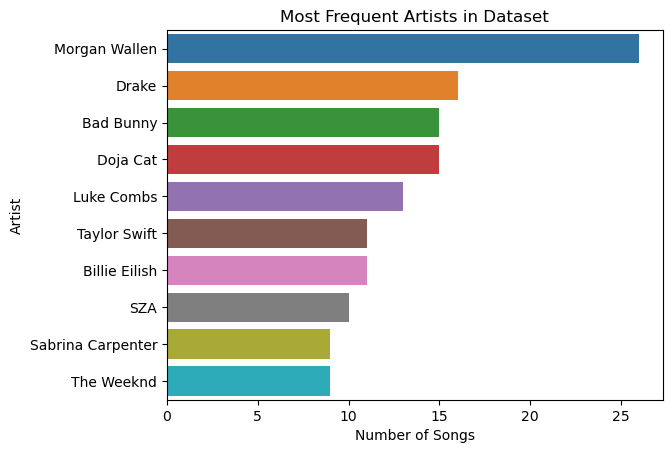

In [31]:
# find the most common artists appearing in the dataset
top_artists = allsongs["artist_clean"].value_counts().head(10)

sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title("Most Frequent Artists in Dataset")
plt.xlabel("Number of Songs")
plt.ylabel("Artist")
plt.show()

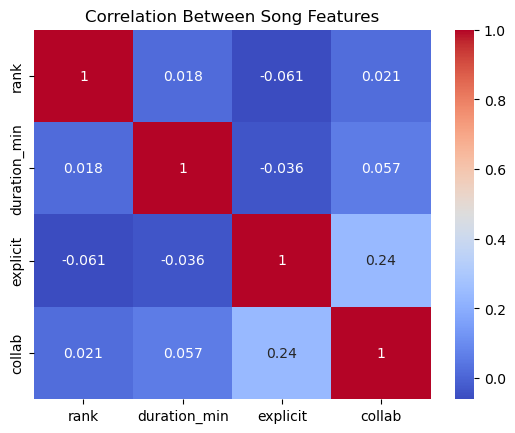

In [32]:
# compute correlation between song features
corr = allsongs[["rank","duration_min","explicit","collab"]].dropna().corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Between Song Features")
plt.show()

# 1st QUESTION: ARE SONGS SHORTER

In [33]:
# calculate average song length by year
allsongs.groupby("year")["duration_min"].mean()

year
2020    3.256406
2021    3.225867
2022    3.274536
2023    3.284033
2024    3.335783
2025    3.374606
Name: duration_min, dtype: float64

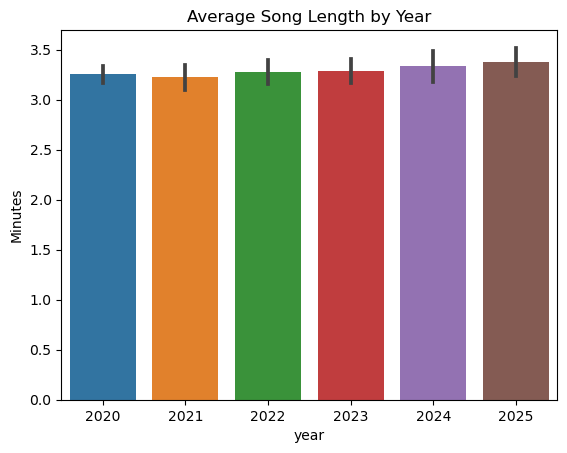

In [34]:
# barplot of the average song length comparison
sns.barplot(data=allsongs, x="year", y="duration_min")
plt.title("Average Song Length by Year")
plt.ylabel("Minutes")
plt.show()

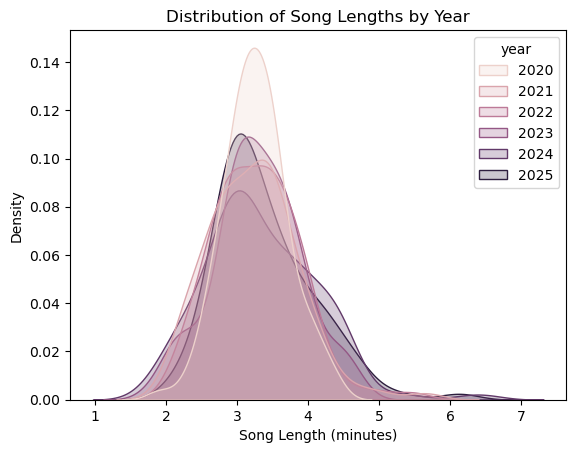

In [35]:
# kde plot showing distribution of song lengths
sns.kdeplot(data=allsongs, x="duration_min", hue="year", fill=True)
plt.xlabel("Song Length (minutes)")
plt.title("Distribution of Song Lengths by Year")
plt.show()

for above, The KDE distribution shows that most songs across all years are approximately three minutes long. However, later years display slightly wider distributions with more longer songs, suggesting a small increase in song length variability over time.

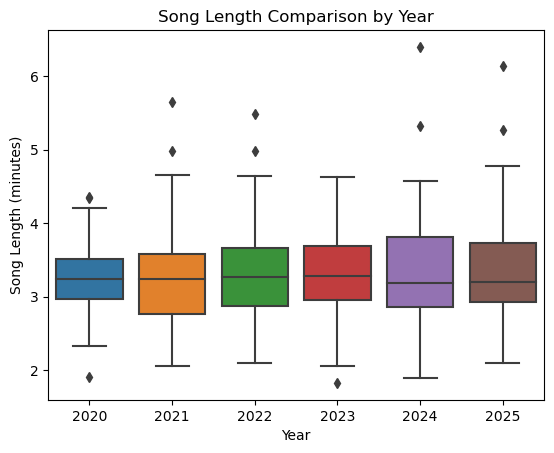

In [36]:
# box plot to compare song length distributions
sns.boxplot(data=allsongs, x="year", y="duration_min")
plt.xlabel("Year")
plt.ylabel("Song Length (minutes)")
plt.title("Song Length Comparison by Year")
plt.show()

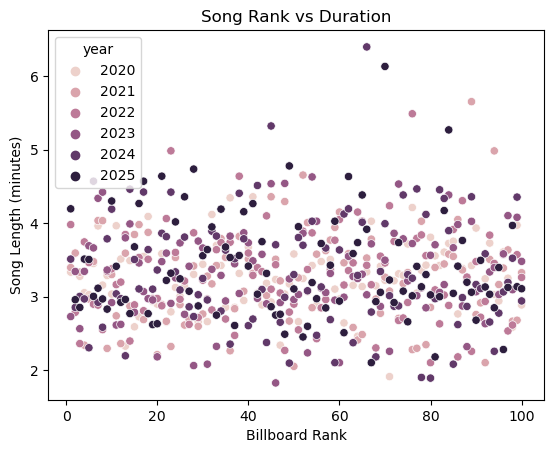

In [37]:
# scatter plot to see if billboard rank is related to song length
sns.scatterplot(data=allsongs, x="rank", y="duration_min", hue="year")
plt.title("Song Rank vs Duration")
plt.xlabel("Billboard Rank")
plt.ylabel("Song Length (minutes)")
plt.show()

for above, we see that Song length does not appear to strongly influence Billboard ranking.

# 2nd QUESTION: ARE SONGS MORE EXPICIT?

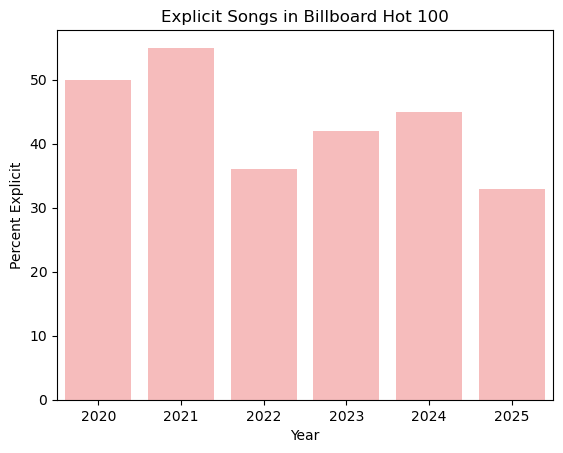

In [38]:
# calculate percent of explicit songs by year
explicit_rate = allsongs.groupby("year")["explicit"].mean().reset_index()
explicit_rate["percent"] = explicit_rate["explicit"] * 100

# visualize explicit song percentages
sns.barplot(data=explicit_rate, x="year", y="percent", color="#ffb3b3")
plt.title("Explicit Songs in Billboard Hot 100")
plt.ylabel("Percent Explicit")
plt.xlabel("Year")
plt.show()

# 3rd QUESTION: ARE SONGS MORE COLLABORATIVE?

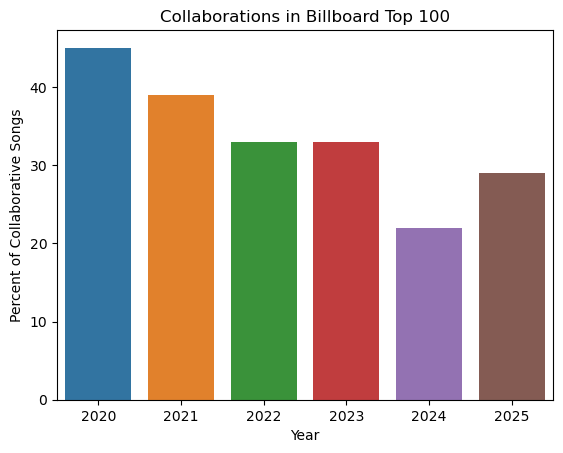

In [39]:
# calculate collaboration rate by year
collab_rate = allsongs.groupby("year")["collab"].mean().reset_index()
collab_rate["collab_percent"] = collab_rate["collab"] * 100

# visualize collaboration rate
sns.barplot(data=collab_rate, x="year", y="collab_percent")
plt.ylabel("Percent of Collaborative Songs")
plt.xlabel("Year")
plt.title("Collaborations in Billboard Top 100")
plt.show()

In [40]:
# create readable labels for solo vs collaborative songs
allsongs["collab_label"] = allsongs["collab"].map({
    False: "Solo",
    True: "Collaboration"
})

allsongs.head(10)

,rank,song,artist,year,artist_clean,duration_ms,explicit,collab,duration_min,collab_label
0,1,Blinding Lights,The Weeknd,2020,The Weeknd,200040,False,False,3.334000,Solo
1,2,Circles,Post Malone,2020,Post Malone,215280,False,False,3.588000,Solo
2,3,The Box,Roddy Ricch,2020,Roddy Ricch,196652,True,False,3.277533,Solo
3,4,Don't Start Now,Dua Lipa,2020,Dua Lipa,183290,False,False,3.054833,Solo
4,5,Rockstar,DaBaby featuring Roddy Ricch,2020,DaBaby,181733,True,True,3.028883,Collaboration
5,6,Adore You,Harry Styles,2020,Harry Styles,207139,False,False,3.452317,Solo
6,7,Life Is Good,Future featuring Drake,2020,Future,237735,True,True,3.962250,Collaboration
7,8,Memories,Maroon 5,2020,Maroon 5,189486,False,False,3.158100,Solo
8,9,The Bones,Maren Morris,2020,Maren Morris,197298,False,False,3.288300,Solo
9,10,Someone You Loved,Lewis Capaldi,2020,Lewis Capaldi,182160,False,False,3.036000,Solo


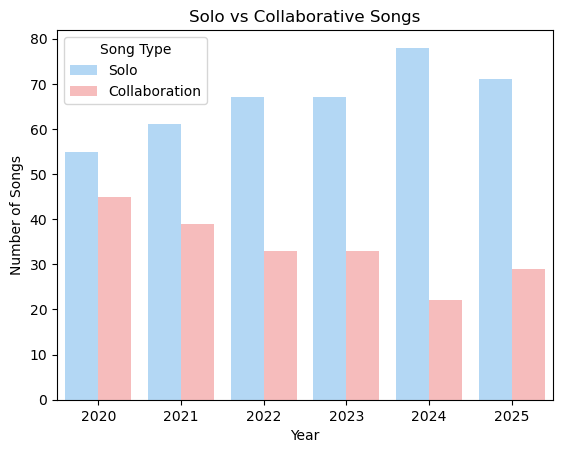

In [41]:
# count plot showing solo vs collaboration counts by year
sns.countplot(
    data=allsongs,
    x="year",
    hue="collab_label",
    palette=["#a8d8ff", "#ffb3b3"]
)

plt.xlabel("Year")
plt.ylabel("Number of Songs")
plt.title("Solo vs Collaborative Songs")

plt.legend(title="Song Type")

plt.show()